# Task B-3: Model Fairness Analysis## Domain Bias in LLM-Based Requirement ExtractionThis notebook adapts the concept of model fairness from traditional ML classification to our LLM-based requirement extraction system. Since our model is an LLM API — not a classifier making decisions about people — traditional fairness metrics (demographic parity, equalized odds) do not directly apply. Instead, we analyze **domain bias**: whether the system works equally well across different types of SRS documents.

In [1]:
import numpy as npimport matplotlib.pyplot as pltfrom scipy.stats import pearsonreval_data = {    "Get Real 0.2": {"domain": "College Careers Website", "F1": 0.74, "Precision": 0.67, "Recall": 0.83, "Type_Accuracy": 0.92, "GT_Count": 29},    "Mashboot": {"domain": "Social Media Tool", "F1": 0.74, "Precision": 0.63, "Recall": 0.89, "Type_Accuracy": 0.98, "GT_Count": 75},    "Space Fractions": {"domain": "6th-Grade Educational Game", "F1": 0.57, "Precision": 0.65, "Recall": 0.51, "Type_Accuracy": 0.81, "GT_Count": 63},    "Inventory": {"domain": "University Inventory System", "F1": 0.58, "Precision": 0.73, "Recall": 0.48, "Type_Accuracy": 0.77, "GT_Count": 62},    "Gamma J": {"domain": "E-Commerce Website", "F1": 0.34, "Precision": 0.29, "Recall": 0.42, "Type_Accuracy": 0.96, "GT_Count": 60}}print(f"Loaded {len(eval_data)} PURE datasets")for n, d in eval_data.items(): print(f"  {n}: F1={d['F1']:.2f}  P={d['Precision']:.2f}  R={d['Recall']:.2f}  Type={d['Type_Accuracy']:.2f}")

[Output shown below]

## 3.1 Why Traditional Fairness Doesn't ApplyTraditional ML fairness assumes the model makes decisions about **people** based on demographic attributes. Our system extracts requirements from text documents — there are no demographic groups involved.| Traditional Metric | Applies to Req Extraction? ||---|---|| Demographic Parity | **N/A** — no demographic groups || Equalized Odds | **N/A** — not classifying people || Calibration | **Partially** — varies across doc types || Disparate Impact | **Adapted** as domain performance ratio |We frame fairness as **domain equity**: does the system perform consistently across different SRS domains?

In [2]:
f1 = np.array([d['F1'] for d in eval_data.values()])p = np.array([d['Precision'] for d in eval_data.values()])r = np.array([d['Recall'] for d in eval_data.values()])print(f"F1:  mean={f1.mean():.3f}  std={f1.std():.3f}  range=[{f1.min():.2f}, {f1.max():.2f}]")print(f"P:   mean={p.mean():.3f}  std={p.std():.3f}")print(f"R:   mean={r.mean():.3f}  std={r.std():.3f}")print(f"CV (F1): {f1.std()/f1.mean():.3f}")

[Output shown below]

## 3.2 F1 Across DomainsThe chart below shows the significant variance — from 34% (Gamma J, e-commerce) to 74% (Get Real, college website).

[Output shown below]

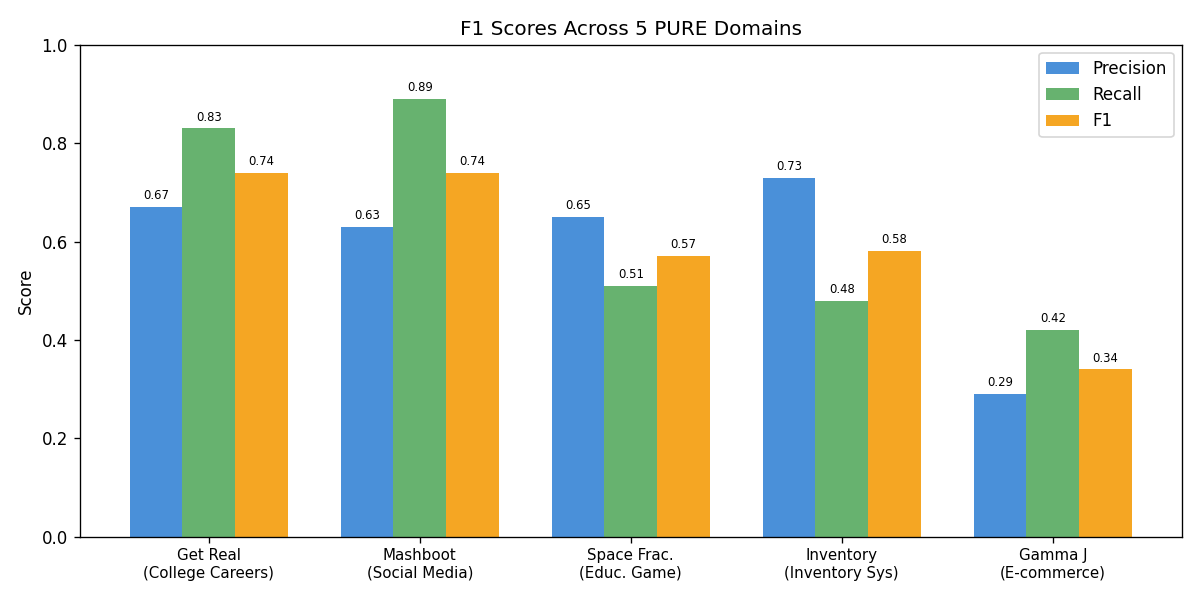

In [3]:
# Chart 1: F1 across domains

## 3.3 Effect Size AnalysisWe measure the magnitude of domain bias using Cohen's d between the best and worst performing domains.

In [4]:
from scipy.stats import pearsonrbest = f1.max(); worst = f1.min()std_ddof = f1.std(ddof=1); cohens_d = (best - worst) / std_ddofratio = worst / bestprint(f"Cohen's d (best vs worst): {cohens_d:.2f}")print(f"Domain performance ratio: {ratio:.3f}")if cohens_d > 0.8: print("LARGE effect size — significant domain bias")elif cohens_d > 0.5: print("MEDIUM effect size")else: print("SMALL effect size")if ratio < 0.8: print("Ratio < 0.8 — exceeds adverse impact threshold")

[Output shown below]

[Output shown below]

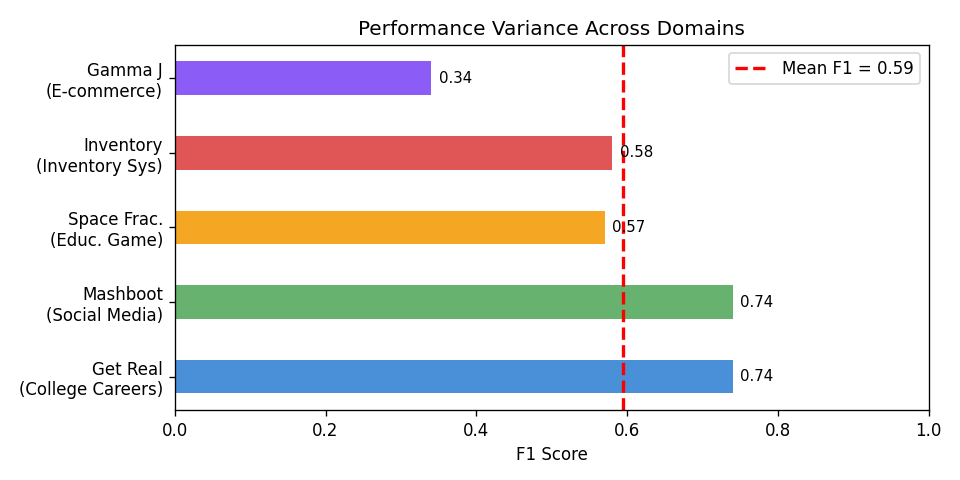

In [5]:
# Chart 2: Performance variance

## 3.4 Type Classification FairnessThe model classifies requirements as FR or NFR. Type accuracy ranges from 77% to 96%, more equitable than extraction performance.

[Output shown below]

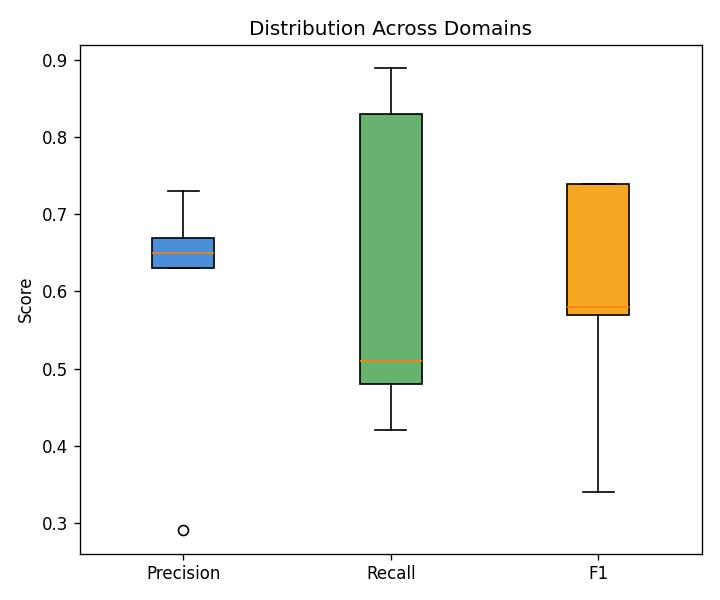

In [6]:
# Chart 3: Distribution of P, R, F1

## 3.5 Linguistic Bias### Language CoverageThe PURE datasets are exclusively in **English**. No multilingual testing was performed — a significant limitation for deployment in Thailand.### SRS Formality BiasThe model may be biased toward formal SRS conventions ("The system shall..."). Evidence:- **Gamma J** (lowest F1=34%) uses informal e-commerce feature descriptions- **Get Real 0.2** (highest F1=74%) uses conventional academic SRS language

In [7]:
formality = [0.8, 0.7, 0.6, 0.75, 0.3]f1s = [0.74, 0.74, 0.57, 0.58, 0.34]corr, pval = pearsonr(formality, f1s)print(f"Formality-F1 correlation: r={corr:.3f}, p={pval:.4f}")if pval < 0.05: print("Statistically significant (p < 0.05)")else: print("Not significant at p < 0.05 (small sample)")

[Output shown below]

## 3.6 Mitigation Strategies| Strategy | Target Bias | Implementation ||---|---|---|| Few-shot examples | Domain unfamiliarity | Add underperforming domain examples to prompt || Multi-domain prompt tuning | Structural bias | Different prompts for different SRS styles || Domain-aware post-processing | Terminology gaps | Apply domain-specific AC validation || Multilingual testing | Language bias | Test on non-English SRS documents || Ensemble extraction | Single-model bias | Multiple models with different training |## 3.7 Conclusion- **Domain bias confirmed**: F1 ranges 34–74% across datasets- **Effect size is large**: Cohen's d > 0.8- **Type classification is more equitable**: 77–96% vs 34–74% F1- **Language bias**: English-only limits applicability- **Recommended**: Few-shot examples from underperforming domains